# RewardLoop: synthetic events and exploration

RewardLoop is a fictional rewards app. This notebook generates its event history from a fixed random seed, then examines activity, category coverage and the reward journey. No company records, customer identifiers, original offer names or company-derived distributions are used.

The generator deliberately includes repeat visits, shallow browsing, campaign entries, voucher checks and mixed category interests. These are modelling assumptions for a portfolio demonstration, not observations about real customers.

## Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd() if (Path.cwd() / 'lib').exists() else Path.cwd().parent
DATA = ROOT / 'Data Analysis' / 'data'
OUTPUT = ROOT / 'Data Analysis' / 'output'
DATA.mkdir(parents=True, exist_ok=True)
OUTPUT.mkdir(parents=True, exist_ok=True)
SEED = 1729
plt.rcParams.update({'figure.figsize': (10, 4.5), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#0f766e','#2563eb','#d97706','#7c3aed','#be185d','#475569']
catalog = json.loads((ROOT / 'lib/reward-catalog.json').read_text())
category_names = list(dict.fromkeys(reward['category'] for reward in catalog))

## Generation assumptions

The dataset contains 1,800 fictional customers observed across 45 days. Each customer receives one of six simulated browsing tendencies with equal probability. Session frequency and progression probabilities differ by tendency. Interests are drawn independently across eight categories; some customers have mixed interests.

A catalogue lookup supplies every reward category. There is no keyword classification or personally identifying information. The generator records screen reach, not completed redemption.

In [2]:
rng = np.random.default_rng(SEED)
N_CUSTOMERS = 1800
N_DAYS = 45
START = pd.Timestamp('2025-01-01')
# Frequency and transition settings are invented, not fitted to company data.
profiles = {
    'browse': dict(sessions=2, listing=.50, click=.35, detail=.85, redeem=.15, entry='home', repeat=2),
    'wallet': dict(sessions=4, listing=.45, click=.40, detail=.90, redeem=.30, entry='voucher', repeat=3),
    'compare': dict(sessions=4, listing=.95, click=.90, detail=.95, redeem=.25, entry='home', repeat=7),
    'bounce': dict(sessions=1, listing=.10, click=.20, detail=.70, redeem=.10, entry=None, repeat=0),
    'trigger': dict(sessions=2, listing=.70, click=.65, detail=.90, redeem=.30, entry='campaign', repeat=4),
    'member': dict(sessions=3, listing=.60, click=.55, detail=.90, redeem=.35, entry='membership', repeat=4),
}
by_category = {c: [r for r in catalog if r['category'] == c] for c in category_names}
records = []
session_number = 0

## Event generation

In [3]:
for customer_number in range(N_CUSTOMERS):
    customer_id = f'SYN-{customer_number + 1:05d}'
    profile = profiles[rng.choice(list(profiles))]
    preferred = str(rng.choice(category_names))
    preference_strength = float(rng.choice([.35, .65, .90]))
    for _ in range(1 + rng.poisson(profile['sessions'])):
        session_number += 1
        session_id = f'SESSION-{session_number:06d}'
        timestamp = START + pd.Timedelta(days=int(rng.integers(N_DAYS)), seconds=int(rng.integers(8*3600, 22*3600)))
        sequence = 0
        chosen_category = preferred if rng.random() < preference_strength else str(rng.choice(category_names))
        reward = by_category[chosen_category][int(rng.integers(3))]
        def record(event, with_reward=False):
            global sequence
            sequence += 1
            records.append(dict(event_id=f'EVT-{len(records)+1:07d}',customer_id=customer_id,session_id=session_id,sequence=sequence,timestamp=(timestamp+pd.Timedelta(seconds=sequence*8)).isoformat(),event=event,reward_id=reward['id'] if with_reward else '',category=reward['category'] if with_reward else ''))
        if profile['entry']:
            for _ in range(max(1,profile['repeat'])):
                record(profile['entry'], profile['entry']=='voucher')
        # An early detail view tests that later ordered progression is still counted.
        if rng.random() < .10:
            record('detail', True)
        record('dashboard')
        if rng.random() > profile['listing']: continue
        record('listing')
        if rng.random() > profile['click']: continue
        record('click', True)
        if rng.random() > profile['detail']: continue
        record('detail', True)
        if profile['entry']=='home' and profile['repeat']>3:
            for _ in range(int(rng.integers(2,7))):
                record('listing'); record('click',True); record('detail',True)
        if rng.random() < .10:
            record('unavailable',True)
            if rng.random() < .5:continue
        if rng.random() < profile['redeem']:record('redeem',True)
events = pd.DataFrame(records).sort_values(['timestamp','session_id','sequence']).reset_index(drop=True)
events.to_csv(DATA / 'synthetic_events.csv',index=False)
print(f"Generated {len(events):,} events, {events.customer_id.nunique():,} customers and {events.session_id.nunique():,} sessions.")

Generated 54,823 events, 1,800 customers and 6,465 sessions.


## Data checks

An event ID must be unique, each session must belong to one customer, and sequence numbers must be unique within a session. Reward events must match the fictional catalogue. Blank reward fields are expected for general app screens.

In [4]:
assert events.event_id.is_unique
assert not events.duplicated(['session_id','sequence']).any()
assert events.groupby('session_id').customer_id.nunique().eq(1).all()
assert events.customer_id.nunique()==N_CUSTOMERS
assert events[['customer_id','session_id','timestamp','event']].notna().all().all()
lookup={r['id']:r['category'] for r in catalog}
reward_events=events[events.reward_id.ne('')]
assert reward_events.reward_id.map(lookup).eq(reward_events.category).all()
assert events.customer_id.str.startswith('SYN-').all()
display(events.head(8))

,event_id,customer_id,session_id,sequence,timestamp,event,reward_id,category
0,EVT-0026867,SYN-00899,SESSION-003262,1,2025-01-01T08:09:18,voucher,nest-home,Shopping & Savings
1,EVT-0026868,SYN-00899,SESSION-003262,2,2025-01-01T08:09:26,voucher,nest-home,Shopping & Savings
2,EVT-0026869,SYN-00899,SESSION-003262,3,2025-01-01T08:09:34,voucher,nest-home,Shopping & Savings
3,EVT-0026870,SYN-00899,SESSION-003262,4,2025-01-01T08:09:42,dashboard,,
4,EVT-0034132,SYN-01135,SESSION-004080,1,2025-01-01T08:10:43,voucher,willow-credit,Shopping & Savings
5,EVT-0034133,SYN-01135,SESSION-004080,2,2025-01-01T08:10:51,voucher,willow-credit,Shopping & Savings
6,EVT-0034134,SYN-01135,SESSION-004080,3,2025-01-01T08:10:59,voucher,willow-credit,Shopping & Savings
7,EVT-0034135,SYN-01135,SESSION-004080,4,2025-01-01T08:11:07,dashboard,,


## Daily activity

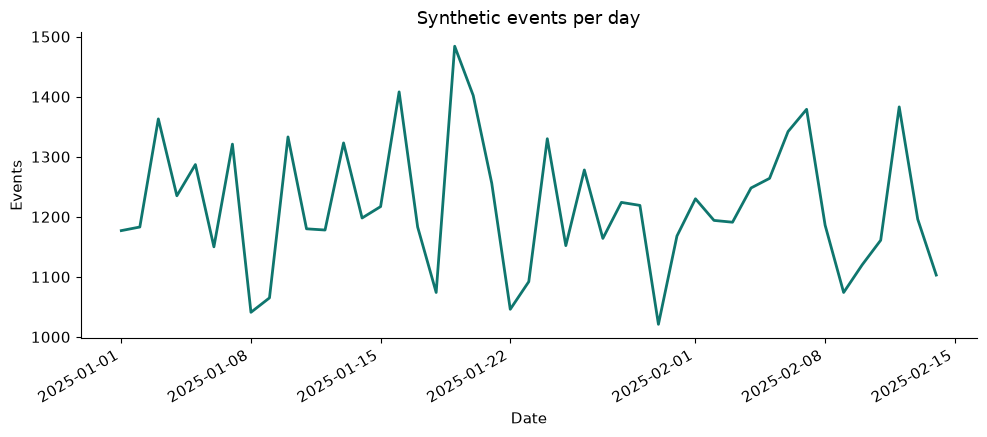

The generated history covers **45 dates**. Daily variation comes from the random session schedule; it does not measure a real campaign effect.

In [5]:
daily = events.groupby(events.timestamp.str[:10]).size().rename('events')
fig, ax=plt.subplots()
ax.plot(pd.to_datetime(daily.index),daily.values,color=COLORS[0],linewidth=2)
ax.set(title='Synthetic events per day',ylabel='Events',xlabel='Date')
fig.autofmt_xdate();plt.tight_layout();plt.show()
display(Markdown(f"The generated history covers **{len(daily)} dates**. Daily variation comes from the random session schedule; it does not measure a real campaign effect."))

## Category activity

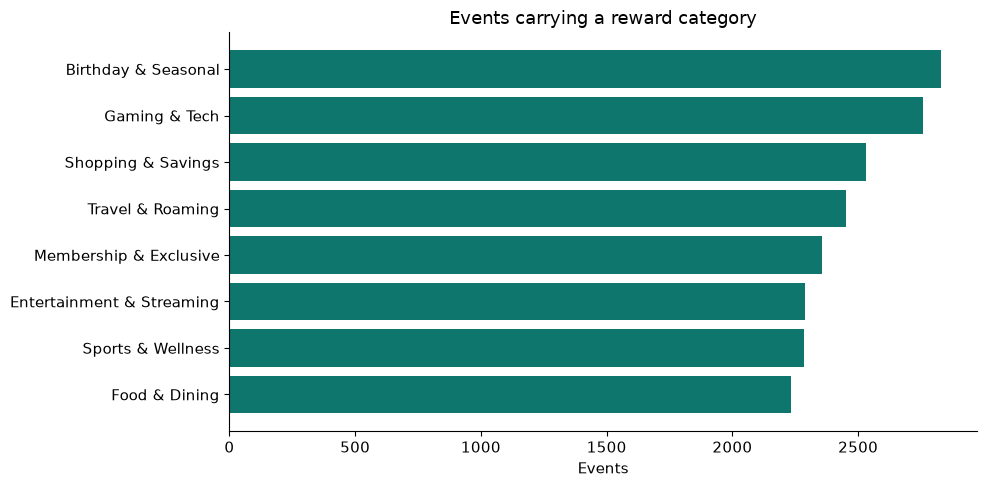

Repeated clicks and voucher checks count as separate events. Category event totals are not customer counts or completed redemptions.

In [6]:
category_counts=reward_events.groupby('category').size().sort_values()
fig,ax=plt.subplots(figsize=(10,5))
ax.barh(category_counts.index,category_counts.values,color=COLORS[0])
ax.set(title='Events carrying a reward category',xlabel='Events')
plt.tight_layout();plt.show()
display(Markdown('Repeated clicks and voucher checks count as separate events. Category event totals are not customer counts or completed redemptions.'))

## Ordered reward journey

The funnel uses distinct sessions. A session reaches a stage only if that event occurs after the preceding stage in the same session. Repeat events are retained. The final stage means the redeem screen was opened; no completed redemption is simulated.

,stage,value,percent
0,Rewards Dashboard,6465,100.00
1,Deal Listing,3880,60.02
2,Deal Click,2460,38.05
3,Deal Detail,2264,35.02
4,Redeem Screen,539,8.34


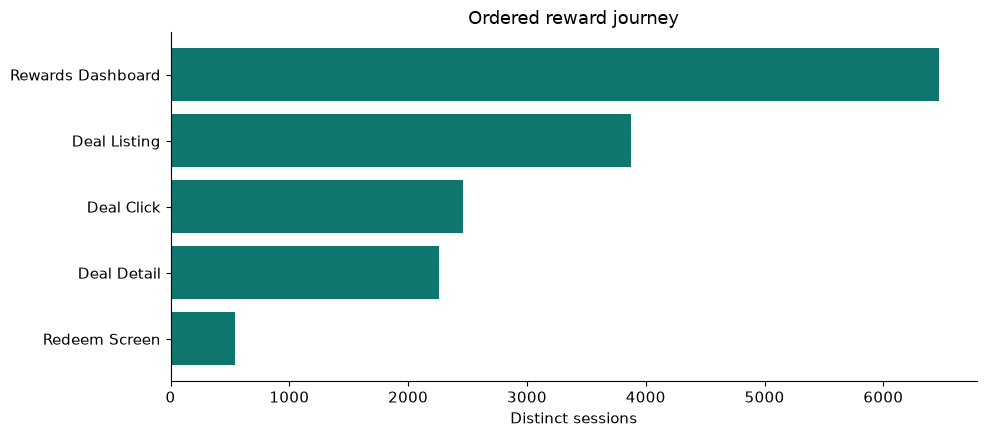

**8.3%** of dashboard sessions reach a redeem screen in order. Drop-offs follow the generator's chosen probabilities, so they cannot validate a business hypothesis.

In [7]:
STAGES=['dashboard','listing','click','detail','redeem']
STAGE_NAMES=['Rewards Dashboard','Deal Listing','Deal Click','Deal Detail','Redeem Screen']
def ordered_reach(frame):
    counts=np.zeros(len(STAGES),dtype=int)
    for _,session in frame.groupby('session_id',sort=False):
        reached=0
        for event in session.sort_values('sequence').event:
            if reached<len(STAGES) and event==STAGES[reached]:
                counts[reached]+=1;reached+=1
    return counts
funnel_counts=ordered_reach(events)
assert np.all(np.diff(funnel_counts)<=0)
fixture=pd.DataFrame({'session_id':['test']*6,'sequence':range(6),'event':['detail','dashboard','listing','click','detail','redeem']})
assert ordered_reach(fixture).tolist()==[1,1,1,1,1]
funnel=[dict(stage=name,value=int(value),percent=round(value/funnel_counts[0]*100,2),display=f'{value:,}') for name,value in zip(STAGE_NAMES,funnel_counts)]
display(pd.DataFrame(funnel)[['stage','value','percent']])
fig,ax=plt.subplots()
ax.barh(STAGE_NAMES[::-1],funnel_counts[::-1],color=COLORS[0])
ax.set(title='Ordered reward journey',xlabel='Distinct sessions')
plt.tight_layout();plt.show()
display(Markdown(f"**{funnel_counts[-1]/funnel_counts[0]:.1%}** of dashboard sessions reach a redeem screen in order. Drop-offs follow the generator's chosen probabilities, so they cannot validate a business hypothesis."))

## Saved source summary

In [8]:
profile=dict(synthetic=True,seed=SEED,events=len(events),customers=int(events.customer_id.nunique()),sessions=int(events.session_id.nunique()),minDate=daily.index.min(),maxDate=daily.index.max(),days=len(daily),funnel=funnel)
(OUTPUT/'source_profile.json').write_text(json.dumps(profile,indent=2))
print('Saved synthetic_events.csv and source_profile.json. Notebook 2 uses these outputs.')

Saved synthetic_events.csv and source_profile.json. Notebook 2 uses these outputs.
